### [문제] 타이타닉 폴더에 있는 train.csv파일을 사용하여 아래 문제에 대한 답을 작성하시오.
<처리조건>
 matplotlib 라이브러리를 사용한다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("train.csv")

df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


### (1) Survived 컬럼의 생존자와 사망자 수를 구하여 막대 그래프로 나타내시오.

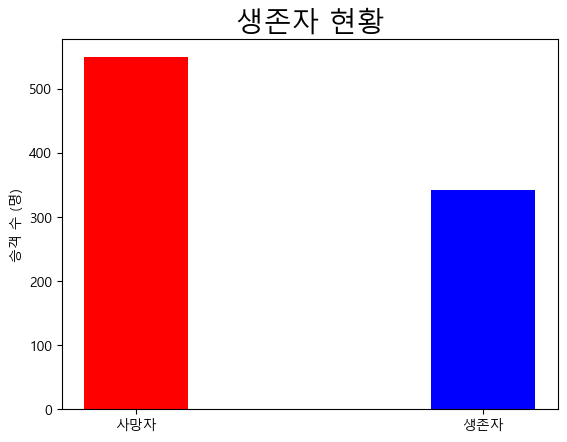

In [2]:
df_1 = df["Survived"].value_counts()

X = [0, 1]
Y = df_1.sort_index().values

xlabel = ["사망자", "생존자"]
color = ['r', 'b']

plt.title("생존자 현황", fontsize=20)
plt.bar(X, Y, color=color, width=0.3, tick_label=xlabel)
plt.ylabel("승객 수 (명)")
plt.show()

### (2) Survived 컬럼의 생존자와 사망자 수를 등급별로 구하여 누적막대그래프로 나타내시오. 등급을 누적으로 나타낸다.

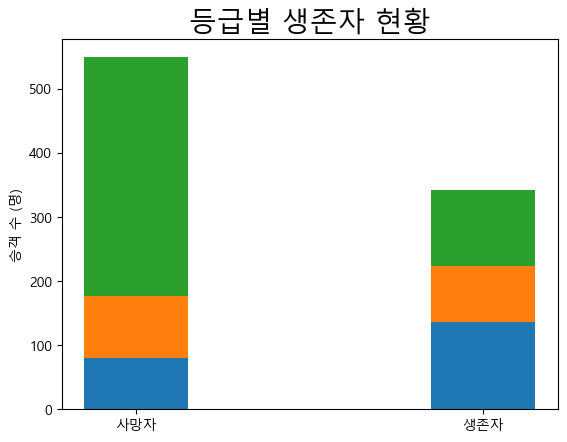

In [3]:
df_2 = df.groupby(["Pclass", "Survived"])["Survived"].value_counts()

X = [0, 1]
Y = df_2.values
sumY = np.zeros(len(X))

xlabel = ["사망자", "생존자"]

plt.title("등급별 생존자 현황", fontsize=20)
plt.xticks(X, xlabel)
for pclass in df["Pclass"].value_counts().sort_index().index:
    Y = df_2[pclass].values

    plt.bar(X, Y, width=0.3, bottom=sumY)
    sumY += Y

plt.ylabel("승객 수 (명)")
plt.show()

### (3) Embarked 컬럼의 탑승지역의 분포를 파이차트로 나타내는데 각 탑승지역에 해당하는 비율을 파이차트에 출력하시오.

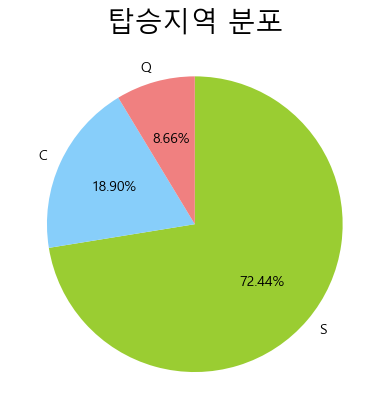

In [4]:
df_3 = df["Embarked"].value_counts()

colors = ['yellowgreen', 'lightskyblue','lightcoral']

plt.title("탑승지역 분포", fontsize=20)
plt.pie(df_3.values, labels=df_3.index, autopct='%1.2f%%', colors=colors, startangle=90, counterclock=False)
plt.show()

### (4) Age컬럼을 10대미만, 10대, 20대, 30대, 40대, 50대, 60대, 70대, 80대 구간으로 나누어 히스트그램을 나타내시오.

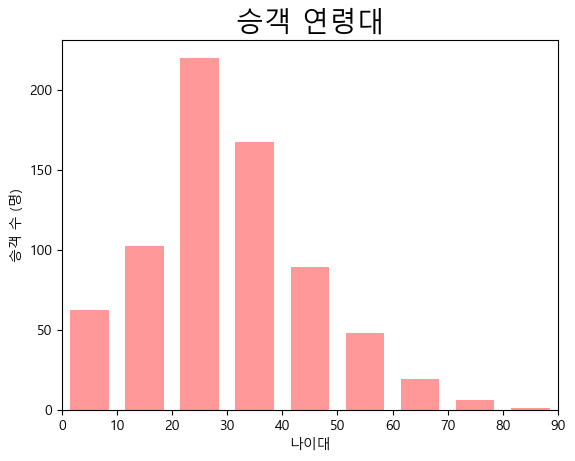

In [5]:
df_4 = df["Age"]

X = list(range(0, 91, 10))

plt.title("승객 연령대", fontsize=20)
plt.hist(df_4, bins=X, rwidth=0.7, color='red', alpha=0.4)
plt.xlim(0, 90)
plt.xlabel("나이대")
plt.ylabel("승객 수 (명)")
plt.show()